<a href="https://colab.research.google.com/github/muzammilibm/Claims-Reporting-Automation-System/blob/main/healthcare_claims_auto_adjudication_rate_ui.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pandas matplotlib seaborn

       CLAIMS ADJUDICATION REPORT SUMMARY       
Total Claims Processed:  10,000
Total Auto-Adjudicated:  8,212
Total Manual Review:     1,788
Auto-Adjudication Rate:  82.12%
Target Status:           UNDER TARGET (<85%)


/tmp/ipykernel_902/2326803256.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='Blues_r')


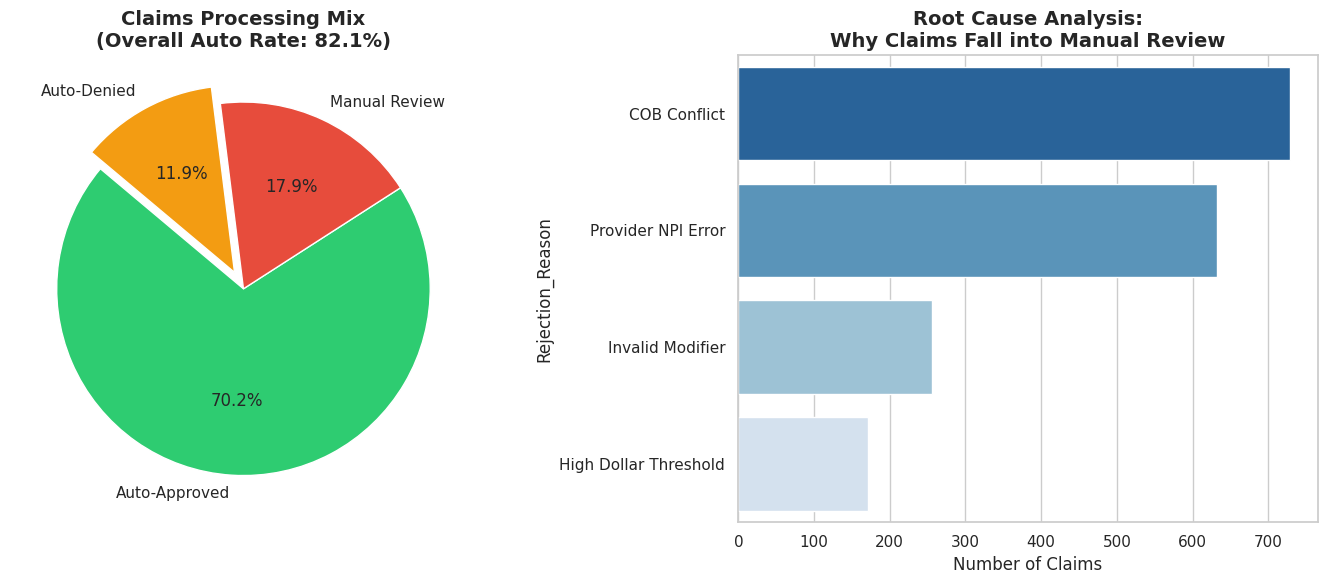

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for consistent results
np.random.seed(42)

# ==========================================
# 1. CREATE MOCK HEALTHCARE CLAIMS DATA
# ==========================================
num_claims = 10000

data = {
    'Claim_ID': [f'CLM-{i:06d}' for i in range(1, num_claims + 1)],
    'Claim_Type': np.random.choice(['Inpatient', 'Outpatient', 'Professional', 'Pharmacy'], size=num_claims, p=[0.15, 0.40, 0.30, 0.15]),
    'Claim_Value': np.round(np.random.exponential(scale=250, size=num_claims) + 20, 2),
    'Status': np.random.choice(['Auto-Approved', 'Auto-Denied', 'Manual Review'], size=num_claims, p=[0.70, 0.12, 0.18])
}

df = pd.DataFrame(data)

# Inject some patterns for analysis: Make high-value claims go to manual review more often
df.loc[df['Claim_Value'] > 1500, 'Status'] = 'Manual Review'

# Inject reasons for the claims that went to manual review
manual_reasons = ['COB Conflict', 'Provider NPI Error', 'Invalid Modifier', 'High Dollar Threshold']
df['Rejection_Reason'] = np.where(
    df['Status'] == 'Manual Review',
    np.random.choice(manual_reasons, size=num_claims, p=[0.40, 0.35, 0.15, 0.10]),
    'N/A - Clean Claim'
)

# ==========================================
# 2. REPORTING LAYER (The "What")
# ==========================================
total_claims = len(df)
auto_processed = len(df[df['Status'].str.startswith('Auto')])
manual_processed = len(df[df['Status'] == 'Manual Review'])

auto_adjudication_rate = (auto_processed / total_claims) * 100

print("=" * 50)
print("       CLAIMS ADJUDICATION REPORT SUMMARY       ")
print("=" * 50)
print(f"Total Claims Processed:  {total_claims:,}")
print(f"Total Auto-Adjudicated:  {auto_processed:,}")
print(f"Total Manual Review:     {manual_processed:,}")
print(f"Auto-Adjudication Rate:  {auto_adjudication_rate:.2f}%")
print(f"Target Status:           {'TARGET MET (>=85%)' if auto_adjudication_rate >= 85 else 'UNDER TARGET (<85%)'}")
print("=" * 50)

# ==========================================
# 3. VISUALIZATION PROTOTYPE (The Dashboard)
# ==========================================
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Chart 1: Overall Processing Mix (Pie Chart)
plt.subplot(1, 2, 1)
status_counts = df['Status'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0, 0, 0.1))
plt.title(f'Claims Processing Mix\n(Overall Auto Rate: {auto_adjudication_rate:.1f}%)', fontsize=14, fontweight='bold')

# Chart 2: Root Cause Analysis for Manual Claims (Bar Chart)
plt.subplot(1, 2, 2)
manual_df = df[df['Status'] == 'Manual Review']
reason_counts = manual_df['Rejection_Reason'].value_counts()
sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='Blues_r')
plt.title('Root Cause Analysis:\nWhy Claims Fall into Manual Review', fontsize=14, fontweight='bold')
plt.xlabel('Number of Claims')

plt.tight_layout()
plt.show()
